# Lab 1 · EDA and simple baselines
Pairs · 24 September 2026, 12:30 Santiago · 6% NP.
Read the brief and rubric first. Supplied code supports execution; replace the written prompts and add your own analysis cells. MODE="synthetic" is fictional practice only. Real submission uses snapshot.

In [70]:
from pathlib import Path
import sys, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
for p in (Path.cwd(), *Path.cwd().parents):
    if (p/'labs/lab_01/lab01_support_v1.py').exists():
        ROOT=p; break
else:
    raise FileNotFoundError('Extract the full package and run inside it.')
sys.path.insert(0,str(ROOT/'labs/lab_01'))
from lab01_support_v1 import load_sources,merge_sources,majority_from_train,evaluate
MODE="snapshot"
print('DATA MODE:', MODE, '| Python:',platform.python_version(),'| pandas:',pd.__version__)

DATA MODE: snapshot | Python: 3.13.5 | pandas: 2.2.3


## 1. Target and audit
State the prediction moment, unit, population and target. Distinguish final classification from completing a race. Explain the source limitations.

### Prediction moment

We predict **after qualifying has finished and before the Grand Prix starts**. The only predictor is `qualifying_position` from the **qualifying table**. We do not use `grid` from the results table: it is published together with the race result, it already includes post-qualifying grid penalties and pit-lane starts (`grid = 0`), and the brief fixes qualifying position as the pre-race information. Position, points, status and laps are post-race information: we use them only to audit and explore the training data, never as predictors.

### Unit

One observation is **one driver in one Grand Prix**, identified by the key `(season, round, driver_id)`.

### Population

The population is **every driver/race record in the supplied race-results snapshots**. For training that means all drivers in 2019–2021 (1,200 rows), not a single driver. We keep every row: retirements, non-finishers, withdrawn and disqualified entries, and entries with a missing qualifying record. This is a *retrospective* population built from who appears in the results table. It is not the entry list that was known before each race.

### Target

`target_top10 = 1` when the source's numeric final race position is 1–10, and `0` otherwise. This is **final classification**, which is not the same as:
- **completing the race**: a driver can retire and still be classified by the laps they completed, and a driver who finishes 11th or lower is a 0;
- **scoring points**: points also depend on scoring rules such as the fastest-lap bonus, half points and later penalties;
- winning, or a constructor result.

### Data limitations

The snapshot reflects results as they are recorded *today*, so it can include corrections made after a race (for example a post-race time penalty or a disqualification that moved a driver out of the top ten). It is therefore not an exact reconstruction of what was known at the historical prediction moment. The population is also retrospective: drivers who were entered but never appear in the results table are invisible to us. Finally, a few results rows have no qualifying record, so the qualifying rule has to fall back to the training majority for them.

In [71]:
q_train,r_train=load_sources('train',ROOT,MODE)
train=merge_sources(q_train,r_train)
display(pd.DataFrame({'qualifying':q_train.groupby('season').size(),'results':r_train.groupby('season').size()}))
display(train.groupby('season').agg(rows=('driver_id','size'),missing_qualifying=('qualifying_position',lambda x:x.isna().sum())))
assert len(train)==len(r_train)
display(train['qualifying_match'].value_counts())

,qualifying,results
season,,
2019,418,420
2020,340,340
2021,439,440


,rows,missing_qualifying
season,,
2019,420,2
2020,340,0
2021,440,1


qualifying_match
both          1197
left_only        3
right_only       0
Name: count, dtype: int64

### Data integrity checks

We audit the **full training population** (all drivers, 2019–2021) and cover: keys, duplicates, unmatched records in both directions, missingness, coverage by season, final classification vs completing the race, and qualifying position vs grid.

In [72]:
# Audit of the full training population (all drivers, 2019-2021).
KEYS = ['season', 'round', 'driver_id']

# 1. Keys: nulls and duplicates in each source and in the merged table
key_check = pd.DataFrame({
    name: {'rows': len(df),
           'null_keys': int(df[KEYS].isna().any(axis=1).sum()),
           'duplicate_keys': int(df.duplicated(KEYS).sum())}
    for name, df in [('qualifying', q_train), ('results', r_train), ('merged', train)]
}).T
print('================================================================================')
print('Key audit: rows, null keys, duplicate keys')
display(key_check)


# 2. Unmatched records in both directions.
# A left join from results only shows results without qualifying (left_only). Qualifying rows with no
# race result can never appear in it, so we check them with an anti-join from the qualifying side.
q_side = q_train[KEYS].merge(r_train[KEYS], on=KEYS, how='left', indicator=True)
print('================================================================================')
print('Unmatched records:')
print('Results rows without a qualifying record (left_only):', int(train['qualifying_match'].eq('left_only').sum()))
print('Qualifying rows without a race result (qualifying-only):', int(q_side['_merge'].eq('left_only').sum()))

# 3. Missingness per column, and the rows that will need the missing-qualifying fallback
missing = train.isna().sum()
print('================================================================================')
print('Missing values per column:')
display(missing[missing > 0].rename('missing_rows').to_frame())
print('=================================================================================')
print('Rows with missing qualifying position (will need fallback):', int(train['qualifying_position'].isna().sum()))
display(train.loc[train['qualifying_position'].isna(),
                  ['season', 'round', 'race_name', 'driver_id', 'constructor_id', 'grid', 'position', 'status']])

# 4. Coverage by season
coverage = train.groupby('season').agg(
    races=('round', 'nunique'),
    drivers=('driver_id', 'nunique'),
    rows=('driver_id', 'size'),
    missing_qualifying=('qualifying_position', lambda x: int(x.isna().sum())),
    target_rate=('target_top10', 'mean'),
)
coverage['rows_per_race'] = coverage['rows'] / coverage['races']
print('=================================================================================')
print('Coverage by season:')
display(coverage.round(3))

# 5. Final classification vs completing the race (status is post-race: audit only, not a predictor)
completed = train['status'].eq('Finished') | train['status'].str.match(r'^\+\d+ Laps?$')
print('=================================================================================')
print('Rows with status indicating the driver completed the race:', int(completed.sum()), 'of', len(completed))
display(pd.crosstab(train['target_top10'], completed.map({True: 'completed race', False: 'did not complete'}),
                    margins=True))
print('=================================================================================')
print('Rows with non-numeric position_text (DNF, DNS, DSQ, etc.):', int(train['position_text'].str.isdigit().eq(False).sum()), 'of', len(train))
display(train['position_text'].astype(str).value_counts()
        .loc[lambda s: ~s.index.str.isdigit()].rename('rows').to_frame())
print('=================================================================================')
print('Rows with points > 0:', int(train['points'].gt(0).sum()), 'of', len(train))
display(pd.crosstab(train['target_top10'], train['points'].gt(0).map({True: 'points > 0', False: 'no points'})))


# 6. Qualifying position vs results grid (why grid is not our predictor)
has_q = train['qualifying_position'].notna()
print('=================================================================================')
print('Rows where grid differs from qualifying position:',
      int((train.loc[has_q, 'grid'] != train.loc[has_q, 'qualifying_position']).sum()), 'of', int(has_q.sum()))
print('Rows with grid = 0 (pit-lane start):', int(train['grid'].eq(0).sum()))

Key audit: rows, null keys, duplicate keys


,rows,null_keys,duplicate_keys
qualifying,1197,0,0
results,1200,0,0
merged,1200,0,0


Unmatched records:
Results rows without a qualifying record (left_only): 3
Qualifying rows without a race result (qualifying-only): 0
Missing values per column:


,missing_rows
qualifying_position,3


Rows with missing qualifying position (will need fallback): 3


...

Rows with non-numeric position_text (DNF, DNS, DSQ, etc.): 155 of 1200


,rows
position_text,
R,146
W,6
D,3


Rows with points > 0: 600 of 1200


points,no points,points > 0
target_top10,,
0,600,0
1,0,600


Rows where grid differs from qualifying position: 381 of 1197
Rows with grid = 0 (pit-lane start): 29


### Audit findings

- **Rows and keys:** qualifying has 418 / 340 / 439 rows and results 420 / 340 / 440 rows for 2019 / 2020 / 2021. No source has null or duplicate `(season, round, driver_id)` keys, and the merged table keeps exactly the 1,200 results rows (`assert len(train)==len(r_train)` passes).
- **Unmatched records:** 1,197 rows match (`both`). **3 results rows have no qualifying record** (`left_only`): two in the 2019 Chinese GP and one in the 2021 Monaco GP. **No qualifying row lacks a race result**, so no qualifying-only record exists in train.
- **Missingness:** `qualifying_position` is missing only for those 3 rows (2 in 2019, 1 in 2021). They stay in the population and will use the training-majority fallback in the qualifying baseline. One of them (2019 Chinese GP, pit-lane start, final position 10) is a target-1 row, so the fallback of 0 would produce a false negative on it.
- **Coverage:** 21 / 17 / 22 races, with exactly 20 rows per race in every season. 2020 is shorter (COVID calendar) and has 23 different drivers because of substitutes. The training target rate is **exactly 0.500** (600 of 1,200) because each race has 10 classified top-ten places out of 20 rows. The majority is therefore an exact tie, which the fixed rule resolves to **0**.
- **Classification vs completing the race:** 176 rows did not complete the race (146 `R`, 6 `W`, 3 `D`, plus other non-finishing statuses). In 2019–2021 none of them was classified in the top ten, but they are still kept as target-0 rows. 424 drivers completed the race and still got a 0. In this period `points > 0` coincides with `target_top10` for all 1,200 rows. That is an observed fact for these seasons, not the definition we use.
- **Grid vs qualifying:** grid differs from qualifying position in 381 of the 1,197 rows that have qualifying (about 32%), and 29 rows have `grid = 0`. This confirms that `grid` carries post-qualifying information and must not replace the qualifying table.

**Decision:** keep all 1,200 rows, predict only from `qualifying_position`, and report the 3 fallback rows explicitly.

### Why the left join instead of the inner join?

The evaluated population is defined by the **results** table: every driver/race record that has a final classification. We therefore start from results and left-join qualifying on `(season, round, driver_id)`. An inner join would silently drop every results row without a qualifying record. In train that removes the 3 `left_only` rows (2019 Chinese GP ×2, 2021 Monaco GP ×1) and shrinks the population from 1,200 to 1,197. Those rows are not random: they are exactly the cases where the qualifying rule cannot be applied. Dropping them would hide the fallback, make the qualifying baseline look like it covers every row, and evaluate the two baselines on a smaller, filtered population instead of the one defined in the brief. The left join keeps them with a null `qualifying_position`, so the missing-qualifying policy stays visible and can be counted in calibration and test.

## 2. EDA question 1
*Question:* How likely is a driver to finish in the top 10, depending on whether they qualified in the top 10 or not?

Train data only (2019–2021). We cross the qualifying top-10 flag (the pre-race information our baseline uses) with the race top-10 target and turn the four combinations into likelihoods within each qualifying group. Rows with a missing qualifying position cannot be placed in either group, so they are reported separately instead of being dropped silently. As a check against the accumulation trap, we also recompute the rates per season to see whether pooling three seasons hides differences.

race_group,Race top 10,Race outside top 10,total
quali_group,,,
Qualified top 10,445,155,600
Qualified 11th or lower,154,443,597


race_group,Race top 10 (%),Race outside top 10 (%)
quali_group,,
Qualified top 10,74.2,25.8
Qualified 11th or lower,25.8,74.2


Rows excluded because qualifying is missing: 3 | their target values: [1, 0, 0]


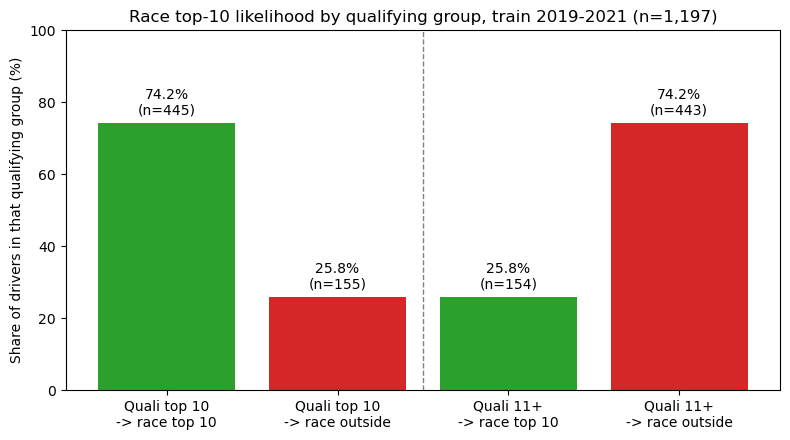

race_top10_rate                                     rows  \
quali_group Qualified 11th or lower Qualified top 10 Qualified 11th or lower   
season                                                                         
2019                          0.274            0.724                     208   
2020                          0.259            0.741                     170   
2021                          0.242            0.759                     219   

                              
quali_group Qualified top 10  
season                        
2019                     210  
2020                     170  
2021                     220

In [73]:
# EDA question 1 (train only): qualifying top 10 vs race top 10
has_q = train['qualifying_position'].notna()
eda1 = train.loc[has_q].copy()
eda1['quali_group'] = np.where(eda1['qualifying_position'].le(10), 'Qualified top 10', 'Qualified 11th or lower')
eda1['race_group'] = np.where(eda1['target_top10'].eq(1), 'Race top 10', 'Race outside top 10')

# Counts and likelihood within each qualifying group (each row of the table sums to 100%)
order_q = ['Qualified top 10', 'Qualified 11th or lower']
order_r = ['Race top 10', 'Race outside top 10']
counts = pd.crosstab(eda1['quali_group'], eda1['race_group']).loc[order_q, order_r]
rates = pd.crosstab(eda1['quali_group'], eda1['race_group'], normalize='index').loc[order_q, order_r]
display(counts.assign(total=counts.sum(axis=1)))
display((rates * 100).round(1).add_suffix(' (%)'))
print('Rows excluded because qualifying is missing:', int((~has_q).sum()),
      '| their target values:', train.loc[~has_q, 'target_top10'].tolist())

# Four bars: how likely each race outcome is, given the qualifying group
labels = ['Quali top 10\n-> race top 10', 'Quali top 10\n-> race outside',
          'Quali 11+\n-> race top 10', 'Quali 11+\n-> race outside']
values = [rates.loc[q, r] * 100 for q in order_q for r in order_r]
ns = [counts.loc[q, r] for q in order_q for r in order_r]
colors = ['tab:green', 'tab:red', 'tab:green', 'tab:red']

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels, values, color=colors)
for bar, v, n in zip(bars, values, ns):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 1.5, f'{v:.1f}%\n(n={n})', ha='center', va='bottom')
ax.axvline(1.5, color='grey', linestyle='--', linewidth=1)
ax.set_ylim(0, 100)  # full 0-100% scale so the bar heights are not exaggerated
ax.set_ylabel('Share of drivers in that qualifying group (%)')
ax.set_title('Race top-10 likelihood by qualifying group, train 2019-2021 (n=1,197)')
plt.tight_layout()
plt.show()

# Accumulation check: does pooling 2019-2021 hide season-level differences?
by_season = (eda1.groupby(['season', 'quali_group'])['target_top10']
             .agg(race_top10_rate='mean', rows='size')
             .unstack('quali_group'))
display(by_season.round(3))

**Answer (observed values).** 

Of the 600 drivers who qualified in the top 10, 445 (74.2%) also finished in the top 10 and 155 (25.8%) did not. Of the 597 who qualified 11th or lower, only 154 (25.8%) finished in the top 10 and 443 (74.2%) did not. So qualifying in the top 10 roughly triples the likelihood of a top-10 finish (74.2% vs 25.8%). The two error groups are almost equal (155 vs 154) because every race has exactly 10 top-10 places: each driver who drops out of the top 10 frees a place for someone who qualified lower.

**Trap check (accumulation/pooling).**

 The pooled rates are not driven by one season. The top-10 qualifiers' rate is 72.4% / 74.1% / 75.9% and the rest's rate is 27.4% / 25.9% / 24.2% for 2019 / 2020 / 2021. The plot uses a full 0–100% axis and shows n on every bar, so the gap is not exaggerated by the framing.

**Consequence for the prediction.**

 Qualifying position is a strong but imperfect pre-race signal. If the qualifying top-10 rule were applied to these training rows, it would be wrong about one time in four in both directions: about 155 false positives and 154 false negatives out of 1,197, which is about 74% accuracy. This supports using the fixed qualifying baseline as the main comparison against the majority rule, which gets 50% here because the target rate is exactly 0.5. Limitations: this is a description of the training years, not a guarantee for 2022–2024, and it shows association only. It also doesn't tell us where the errors happen, for example whether they cluster around P9–P12 near the cutoff. The 3 rows with missing qualifying (targets 1, 0, 0) are outside this table and will use the majority fallback (0).

 ---

## 3. EDA question 2
**Question:** When both drivers of a constructor qualify in the top 10, how often do both finish in the top 10? Does treating teammates as independent observations distort what we expect from the errors?

**Design (train only, 2019–2021):** we group rows by `(season, round, constructor_id)` and keep the pairs where both cars have `qualifying_position` ≤ 10 (the 3 rows with missing qualifying never count). For each pair we count how many cars finished top 10: both, exactly one, or neither. We compare these counts with what we would expect if teammates were independent and shared the same conversion rate *p*: P(both) = *p*², P(exactly one) = 2*p*(1−*p*), P(neither) = (1−*p*)². `target_top10` is only used here for exploration.

**Friday trap checked (independence fallacy):** the unit is "one driver in one race", so it is tempting to treat every row as an independent trial. Teammates share a car, power unit, pit crew and strategy, so their errors may come together.

Constructor-race pairs: 600 | pairs with both cars qualified P1-P10: 226
Top-10 conversion rate of these cars: p = 0.777


,observed,observed_%,expected_if_independent
outcome,,,
both,142,62.8,136.3
exactly one,67,29.6,78.4
neither,17,7.5,11.3


,pairs,both_rate,neither
constructor_id,,,
mercedes,60,0.78,1
red_bull,46,0.63,4
mclaren,35,0.57,3
ferrari,34,0.74,2
renault,15,0.47,1
alphatauri,12,0.08,1
racing_point,9,0.78,0
alpine,5,0.60,0
haas,5,0.20,3


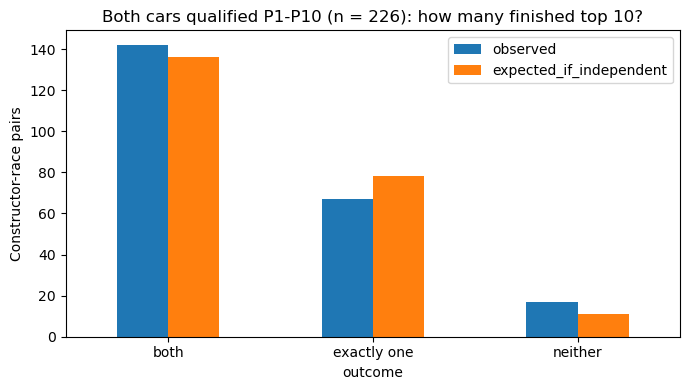

In [74]:
# EDA question 2: pairs where both teammates qualified P1-P10. Train only (2019-2021).
PAIR = ['season', 'round', 'constructor_id']
t = train.copy()
t['q10'] = t['qualifying_position'].le(10)   # missing qualifying (NaN) never counts as Q10

pairs = t.groupby(PAIR).agg(n_q10=('q10', 'sum'), n_top10=('target_top10', 'sum')).reset_index()
both_q = pairs[pairs['n_q10'] == 2].copy()
both_q['outcome'] = both_q['n_top10'].map({2: 'both', 1: 'exactly one', 0: 'neither'})
n = len(both_q)
print('Constructor-race pairs:', len(pairs), '| pairs with both cars qualified P1-P10:', n)

# If teammates were independent with the same conversion rate p:
# P(both) = p^2, P(exactly one) = 2p(1-p), P(neither) = (1-p)^2
p = both_q['n_top10'].sum() / (2 * n)
order = ['both', 'exactly one', 'neither']
table = pd.DataFrame({'observed': both_q['outcome'].value_counts().reindex(order, fill_value=0)})
table['observed_%'] = 100 * table['observed'] / n
table['expected_if_independent'] = n * np.array([p**2, 2 * p * (1 - p), (1 - p)**2])
print(f'Top-10 conversion rate of these cars: p = {p:.3f}')
display(table.round(1))

# Conversion is not the same for every team
by_team = (both_q.groupby('constructor_id')['outcome']
           .agg(pairs='size', both_rate=lambda s: s.eq('both').mean(), neither=lambda s: int(s.eq('neither').sum()))
           .sort_values('pairs', ascending=False))
display(by_team.round(2))

ax = table[['observed', 'expected_if_independent']].plot.bar(rot=0, figsize=(7, 4))
ax.set_ylabel('Constructor-race pairs')
ax.set_title(f'Both cars qualified P1-P10 (n = {n}): how many finished top 10?')
plt.tight_layout(); plt.show()

### Findings, Friday trap and decision

- **Frequency:** 226 of the 600 constructor-race pairs had both cars qualify P1–P10. Both cars finished top 10 in **142 pairs (62.8%)**, exactly one in **67 (29.6%)** and neither in **17 (7.5%)**.
- **Independence check (p = 0.777):** if teammates were independent we would expect 136.3 / 78.4 / 11.3 pairs. We observe more "neither" pairs (17 vs 11.3, about 1.5×) and fewer "exactly one" pairs (67 vs 78.4). Teammates tend to succeed or fail together more than independence predicts.
- **Team strength matters:** the conversion rate is not the same for every team. Both cars finished top 10 in 78% of Mercedes pairs (60 pairs) but only 8% of AlphaTauri pairs (12) and 20% of Haas pairs (5, with 3 "neither"). Part of the excess "neither" pairs comes from mixing strong and weak teams, not only from shared race-day problems.
- **Consequence for the "Qualifying top ten" baseline:** it predicts 1 for both cars in all 226 pairs, i.e. a double top-10 100% of the time vs 62.8% observed. Its false positives here are 67 + 2×17 = 101, and 34 of them come from the 17 pairs where both cars failed together.

**Decision / limitation:** we keep the driver-race unit and the baseline unchanged (the predictor is fixed). When reading calibration errors, we will not treat each false positive as an independent error: some come in teammate pairs from the same team and race. Limitation: only 226 pairs and 17 "neither" events, so the evidence is small, and we do not separate team-strength effects from true shared shocks.

## 4. EDA question 3
Question: TO COMPLETE.

Use train only. Add a table/graph, cite observed values, interpret and state a decision or limitation. At least one of the three analyses must check a Friday trap.

In [75]:
# Add your train-only analysis here.

## 5. Baselines and 2022 check
Explain the two fixed rules, tie handling and missing-qualifying fallback. Predict qualitatively how each might fail before running the check. TO COMPLETE.

In [76]:
majority=majority_from_train(train)
print('Training majority:',majority,'| training target rate:',train.target_top10.mean())
q_cal,r_cal=load_sources('calibration',ROOT,MODE)
cal=merge_sources(q_cal,r_cal)
print('Calibration rows:',len(cal),'| missing qualifying:',cal.qualifying_position.isna().sum())
display(evaluate(cal,majority))

Training majority: 0 | training target rate: 0.5
Calibration rows: 440 | missing qualifying: 0


,n,TN,FP,FN,TP,accuracy,balanced_accuracy
majority,440.0,220.0,0.0,220.0,0.0,0.500000,0.500000
qualifying_top10,440.0,168.0,52.0,52.0,168.0,0.763636,0.763636


Interpret TN/FP/FN/TP, accuracy and balanced accuracy. Explain the positive/negative error costs in this task without inventing monetary values. Record any corrections after the check. TO COMPLETE.

## 6. Freeze before final test
Complete this record and commit the code before enabling RUN_TEST.

- Members and date: TO COMPLETE.
- Target, population, join and prediction moment: TO COMPLETE.
- Baselines, train majority, threshold and missing policy: TO COMPLETE.
- Three analysis decisions and changes after calibration: TO COMPLETE.
- Frozen code commit/version: TO COMPLETE.

The test switch is a learning aid. Accessing CSVs directly still counts as inspecting test. Do not change the method in response to test results. Document genuine later bug fixes transparently.

In [77]:
RUN_TEST=False
if RUN_TEST:
    q_test,r_test=load_sources('test',ROOT,MODE,frozen=True)
    test=merge_sources(q_test,r_test)
    print('Test rows:',len(test),'| missing qualifying:',test.qualifying_position.isna().sum())
    display(evaluate(test,majority))
else:
    print('Test remains unopened by this notebook. Complete and commit the freeze record first.')

Test remains unopened by this notebook. Complete and commit the freeze record first.


## 7. Final interpretation and handoff
Compare calibration and test, cite your observed results, explain one failure mode and what the evidence supports. Discuss the retrospective population and source timing limitation. TO COMPLETE.

Complete RUNBOOK and PROMPTS/contributions; restart/run all and save outputs. Submit the repository URL and final commit via Canvas. No separate report is required.